<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      10000 non-null  int64 
 1   ProductId               10000 non-null  object
 2   UserId                  10000 non-null  object
 3   ProfileName             10000 non-null  object
 4   HelpfulnessNumerator    10000 non-null  int64 
 5   HelpfulnessDenominator  10000 non-null  int64 
 6   Score                   10000 non-null  int64 
 7   Time                    10000 non-null  int64 
 8   Summary                 10000 non-null  object
 9   Text                    10000 non-null  object
dtypes: int64(5), object(5)
memory usage: 781.4+ KB
None
                Id  HelpfulnessNumerator  HelpfulnessDenominator  \
count  10000.00000          10000.000000            10000.000000   
mean    5000.50000              1.573500                2.014900   
std    

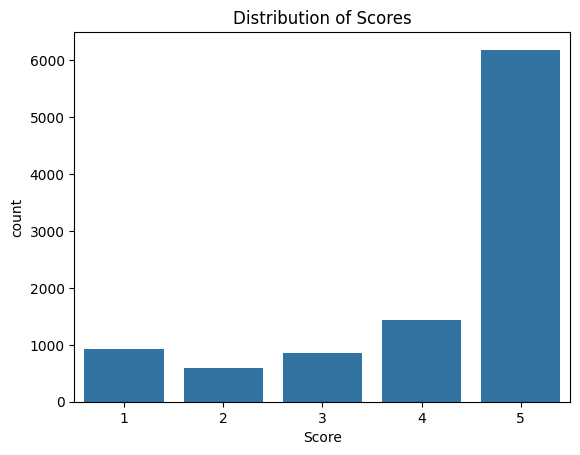

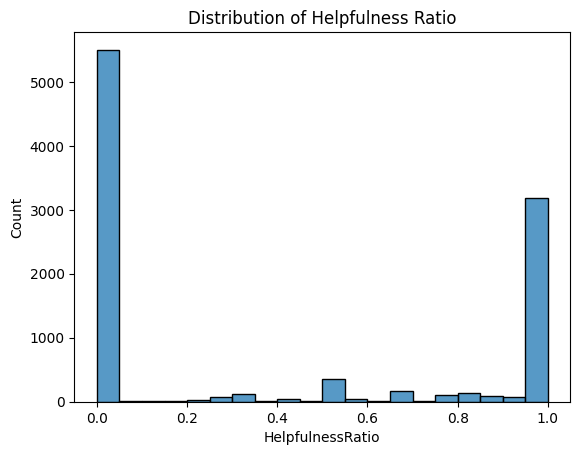

Product: NOUN
arrived: VERB
labeled: VERB
as: ADP
Jumbo: PROPN
Salted: PROPN
Peanuts: PROPN
...: PUNCT
the: DET
peanuts: NOUN
were: AUX
actually: ADV
small: ADJ
sized: ADJ
unsalted: NOUN
.: PUNCT
Not: PART
sure: ADJ
if: SCONJ
this: PRON
was: AUX
an: DET
error: NOUN
or: CCONJ
if: SCONJ
the: DET
vendor: NOUN
intended: VERB
to: PART
represent: VERB
the: DET
product: NOUN
as: ADP
": PUNCT
Jumbo: PROPN
": PUNCT
.: PUNCT


POS Tagging Time: 2.053603410720825
Dependency Parsing Time: 0.03919100761413574
Statistical Parsing Time: 0.039627790451049805


In [28]:
import pandas as pd
import io  # Import the 'io' module

# Load the dataset, verify the delimiter
file_path = '/Reviews.csv'
df = pd.read_csv(file_path, nrows=10000, delimiter=',')  # Try comma as delimiter

# Verify if 'Score' column exists
if 'Score' in df.columns:
    # Exploratory Data Analysis (EDA):
    # • Basic Information:
    print(df.info())
    print(df.describe())
    # Missing Values:
    print(df.isnull().sum())

    # Distribution of Scores:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.countplot(x='Score', data=df)
    plt.title('Distribution of Scores')
    plt.show()
else:
    print("Column 'Score' not found in the DataFrame. Please check your data.")


df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator']
df['HelpfulnessRatio'].fillna(0, inplace=True)
sns.histplot(df['HelpfulnessRatio'], bins=20)
plt.title('Distribution of Helpfulness Ratio')
plt.show()

# Preprocessing:
# Handling Missing Values:
df.dropna(subset=['Text'], inplace=True)
# Text Cleaning:
import re

def clean_text(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = text.lower()
    return text
df['CleanedText'] = df['Text'].apply(clean_text)

# Task 2: Implementing Parsing Algorithms
# 1.	POS Tagging:
import spacy

nlp = spacy.load('en_core_web_sm')

for i in range(2):
    doc = nlp(df['Text'].iloc[i])
for token in doc:
        print(f'{token.text}: {token.pos_}')

# Dependency Parser:
import random
from spacy import displacy

sentences = df[df['Text'].str.split().str.len() >= 10]['Text'].sample(2).tolist()

for sentence in sentences:
    doc = nlp(sentence)
    displacy.render(doc, style='dep', jupyter=True)
# Statistical Parser:
for sentence in sentences:
    doc = nlp(sentence)
    displacy.render(doc, style='ent', jupyter=True)
# Efficiency Comparison:
import time

# POS Tagging
start_time = time.time()
for i in range(100):
    doc = nlp(df['Text'].iloc[i])
pos_time = time.time() - start_time

# Dependency Parsing
start_time = time.time()
for sentence in sentences:
    doc = nlp(sentence)
dep_time = time.time() - start_time

# Statistical Parsing
start_time = time.time()
for sentence in sentences:
    doc = nlp(sentence)
stat_time = time.time() - start_time

print(f'POS Tagging Time: {pos_time}')
print(f'Dependency Parsing Time: {dep_time}')
print(f'Statistical Parsing Time: {stat_time}')
